# Questionnaire Plots From CSV

This notebook reads `questionnaire_results.csv` and recreates the boxplots using the same lecture-style plotting logic: colored boxplots, red median lines, and `x̄` / `IQR` annotations above each box.


In [25]:
import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "csvs/questionnaire_results.csv"
OUTPUT_DIR = "new_svg_plots"
SHOW_PLOTS = True

FONT_NAME = "DejaVu Sans"
ITEM_FIG_HEIGHT = 6
ITEM_WIDTH_PER_BOX = 1.35
ITEM_MIN_WIDTH = 8
OVERALL_FIG_WIDTH = 9
OVERALL_FIG_HEIGHT = 6
BOX_WIDTH = 0.35
MEDIAN_LINEWIDTH = 3
BOX_LINEWIDTH = 1.8
WHISKER_LINEWIDTH = 1.4
CAP_LINEWIDTH = 1.4
ANNOTATION_FONT_SIZE = 10
LABEL_FONT_SIZE = 11
YTICK_FONT_SIZE = 10
YMIN = 1
YMAX = 5.5
YTICKS = [1, 2, 3, 4, 5]

constructs_to_plot = {
    "Perceived Usefulness": {
        "items": ["Q3", "Q4"],
        "color": "#ee895b",
        "display": "Usefulness",
    },
    "Clarity": {
        "items": ["Q5", "Q6", "Q7", "Q8", "Q9"],
        "color": "#25817a",
        "display": "Clarity",
    },
    "Social Expressiveness & Appropriateness": {
        "items": ["Q10", "Q11", "Q12", "Q13", "Q14", "Q15", "Q16"],
        "color": "#d85c64",
        "display": "Expressive / Appropriate",
    },
    "Trust, Safety & Comfort": {
        "items": ["Q17", "Q18", "Q19_R", "Q20_R", "Q21"],
        "color": "#84a5c3",
        "display": "Trust / Safety / Comfort",
    },
}

pretty_item_labels = {
    "Q19_R": "Q19 (rev)",
    "Q20_R": "Q20 (rev)",
}

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [26]:
df = pd.read_csv(CSV_PATH)
data = df.copy()

likert_items = [f"Q{i}" for i in range(3, 22)]
for col in likert_items:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

for col in ["Q19", "Q20"]:
    if col in data.columns:
        data[f"{col}_R"] = data[col].apply(lambda x: 6 - x if pd.notna(x) else np.nan)

for construct_name, settings in constructs_to_plot.items():
    score_col = f"{construct_name}_score"
    data[score_col] = data[settings["items"]].median(axis=1, skipna=True)

data.head()


,age_group,gender,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q21,comment,application_area,image_files,Q19_R,Q20_R,Perceived Usefulness_score,Clarity_score,Social Expressiveness & Appropriateness_score,"Trust, Safety & Comfort_score"
0,21-24,Man,3,2,4,2,2,4,5,2,...,1,The response seem out of sync and the wait bet...,"At homes,","IMG_2712.HEIC,IMG_2714.HEIC",1,1,2.5,4.0,3.0,1.0
1,21-24,Man,2,2,3,4,3,4,4,4,...,2,I liked the robot. I felt the verbal and nonve...,"In homes, hospitals, elderly help, healthcare,...","IMG_2715.HEIC,IMG_2716.HEIC",2,3,2.0,4.0,4.0,2.0
2,21-24,Man,2,2,4,4,5,4,2,4,...,1,NaN,NaN,"IMG_2717.HEIC,IMG_2718.HEIC",1,2,2.0,4.0,4.0,1.0
3,21-24,Woman,4,4,4,3,4,5,4,5,...,4,NaN,"service jobs, hospitality","IMG_2719.HEIC,IMG_2720.HEIC",2,2,4.0,4.0,4.0,3.0
4,21-24,Woman,4,3,2,2,3,4,4,4,...,3,NaN,"manufacturing/service, some simple home tasks","IMG_2722.HEIC,IMG_2723.HEIC",2,2,3.5,3.0,4.0,2.0


In [27]:
def wrap_label(label, max_words=1):
    words = str(label).split()
    return "\n".join(
        " ".join(words[i:i + max_words])
        for i in range(0, len(words), max_words)
    )

def sanitize_filename(name):
    keep = []
    for ch in str(name):
        if ch.isalnum() or ch in ("_", "-", " "):
            keep.append(ch)
    return "".join(keep).strip().replace(" ", "_").lower()

def annotate_box(ax, box, xpos, vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return

    x_bar = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    top_y = box["caps"][1].get_ydata()[0]
    annotation = rf"$\bar{{x}}={x_bar:.2f}$" + "\n" + rf"$\mathrm{{IQR}}={iqr:.2f}$"
    ax.text(xpos, top_y + 0.08, annotation, fontsize=ANNOTATION_FONT_SIZE, va="bottom", ha="center")

def style_axes(ax, ylabel):
    ax.set_ylabel(ylabel, fontsize=LABEL_FONT_SIZE, fontname=FONT_NAME)
    ax.set_ylim(YMIN, YMAX)
    ax.set_yticks(YTICKS)
    ax.tick_params(axis="x", labelsize=LABEL_FONT_SIZE)
    ax.tick_params(axis="y", labelsize=YTICK_FONT_SIZE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

def save_svg(fig, filename):
    plt.rcParams["svg.fonttype"] = "path"
    out_path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(out_path, format="svg", dpi=300, bbox_inches="tight", transparent=True)
    print(f"Saved: {out_path}")


Saved: new_svg_plots/boxplot_perceived_usefulness.svg


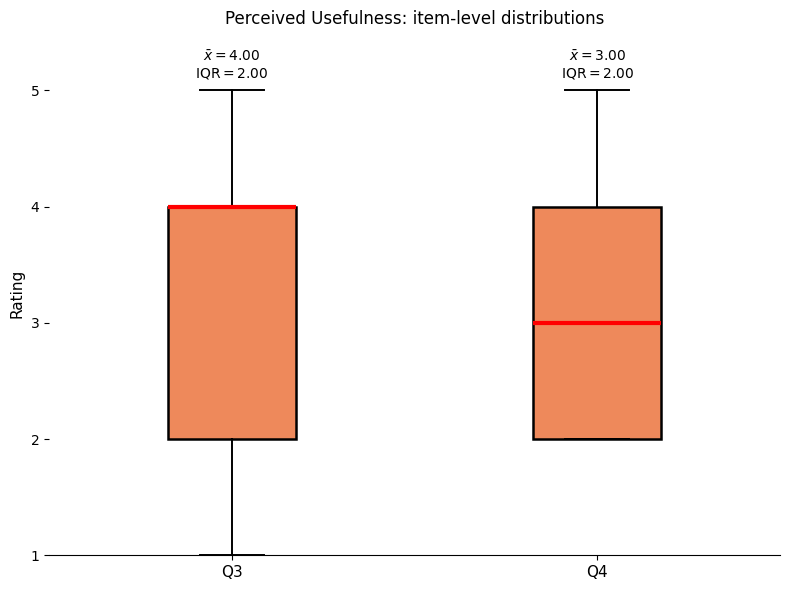

Saved: new_svg_plots/boxplot_clarity.svg


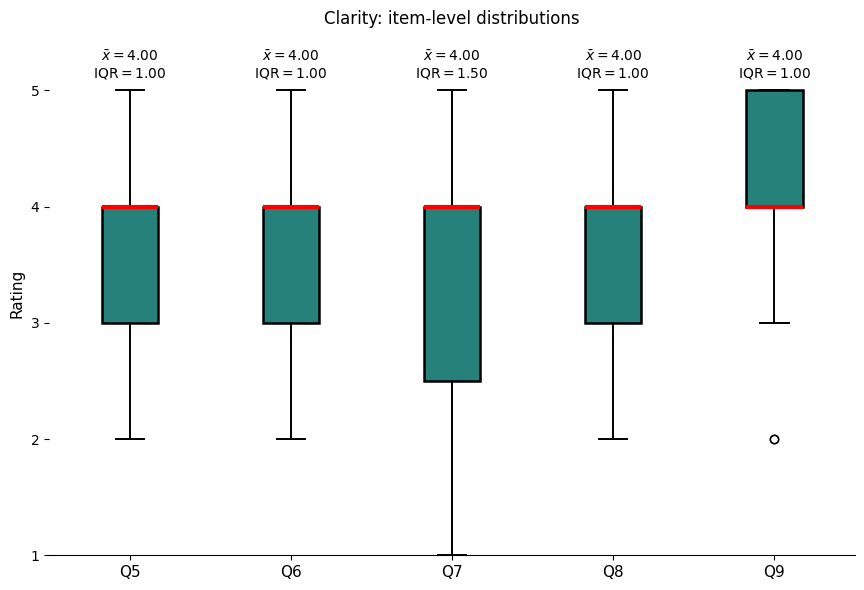

Saved: new_svg_plots/boxplot_social_expressiveness__appropriateness.svg


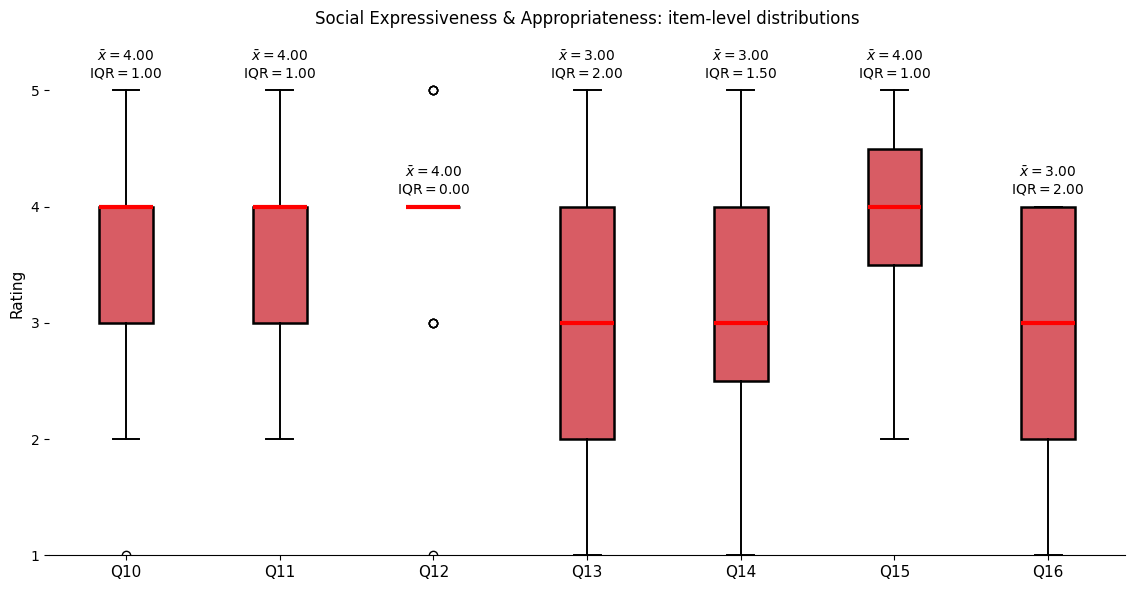

Saved: new_svg_plots/boxplot_trust_safety__comfort.svg


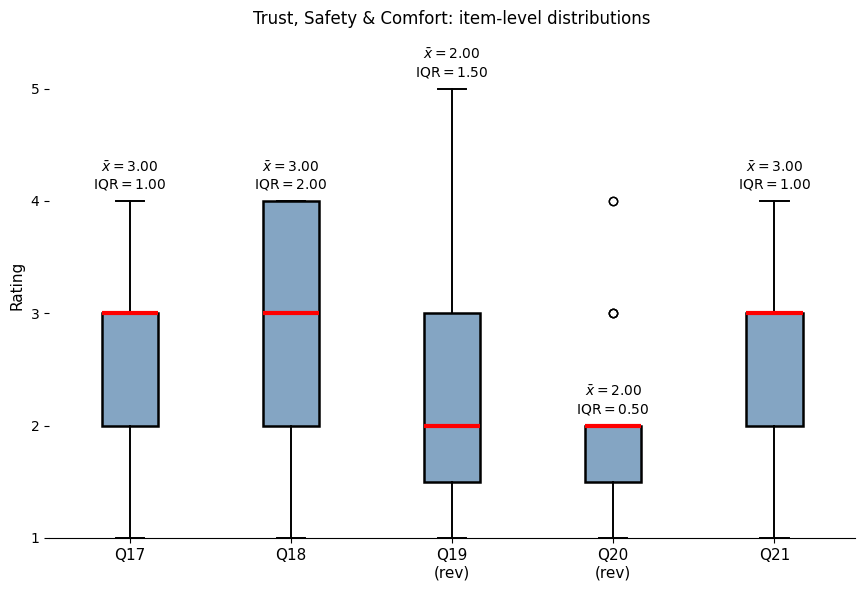

Saved: new_svg_plots/boxplot_all_constructs.svg


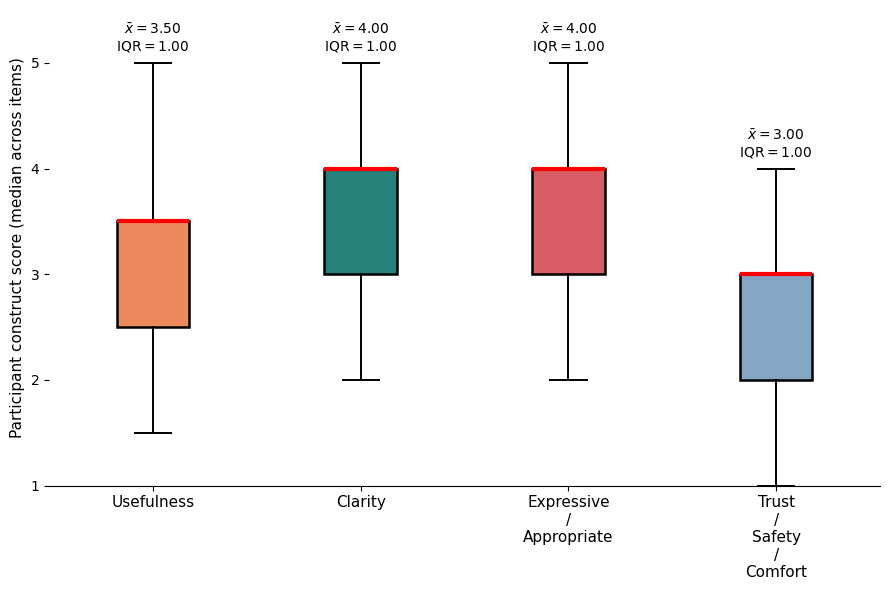

In [28]:
# One lecture-style plot per construct (item-level)
for construct_name, settings in constructs_to_plot.items():
    items = settings["items"]
    color = settings["color"]
    labels = [pretty_item_labels.get(item, item) for item in items]
    wrapped_labels = [wrap_label(label) for label in labels]
    plot_data = [pd.to_numeric(data[item], errors="coerce").dropna().values for item in items]

    fig_width = max(ITEM_MIN_WIDTH, len(plot_data) * ITEM_WIDTH_PER_BOX + 2)
    fig, ax = plt.subplots(figsize=(fig_width, ITEM_FIG_HEIGHT))
    positions = np.arange(len(plot_data))

    for i, vals in enumerate(plot_data):
        box = ax.boxplot(
            vals,
            positions=[positions[i]],
            widths=BOX_WIDTH,
            patch_artist=True,
            notch=False,
            medianprops=dict(color="red", linewidth=MEDIAN_LINEWIDTH),
            whiskerprops=dict(color="black", linewidth=WHISKER_LINEWIDTH),
            capprops=dict(color="black", linewidth=CAP_LINEWIDTH),
            boxprops=dict(linewidth=BOX_LINEWIDTH),
        )
        for patch in box["boxes"]:
            patch.set_facecolor(color)
        annotate_box(ax, box, positions[i], vals)

    ax.set_xticks(positions)
    ax.set_xticklabels(wrapped_labels, fontsize=LABEL_FONT_SIZE, fontname=FONT_NAME)
    style_axes(ax, ylabel="Rating")
    ax.set_title(f"{construct_name}: item-level distributions", fontsize=LABEL_FONT_SIZE + 1, fontname=FONT_NAME)
    fig.tight_layout()
    save_svg(fig, f"boxplot_{sanitize_filename(construct_name)}.svg")

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

# One lecture-style plot across constructs
wrapped_labels = []
aggregated_data = []
colors = []

for construct_name, settings in constructs_to_plot.items():
    score_col = f"{construct_name}_score"
    vals = pd.to_numeric(data[score_col], errors="coerce").dropna().values
    aggregated_data.append(vals)
    colors.append(settings["color"])
    wrapped_labels.append(wrap_label(settings["display"]))

positions = np.arange(len(aggregated_data))
fig, ax = plt.subplots(figsize=(OVERALL_FIG_WIDTH, OVERALL_FIG_HEIGHT))

for i, (label, vals, color) in enumerate(zip(wrapped_labels, aggregated_data, colors)):
    box = ax.boxplot(
        vals,
        positions=[positions[i]],
        widths=BOX_WIDTH,
        patch_artist=True,
        notch=False,
        medianprops=dict(color="red", linewidth=MEDIAN_LINEWIDTH),
        whiskerprops=dict(color="black", linewidth=WHISKER_LINEWIDTH),
        capprops=dict(color="black", linewidth=CAP_LINEWIDTH),
        boxprops=dict(linewidth=BOX_LINEWIDTH),
    )
    for patch in box["boxes"]:
        patch.set_facecolor(color)
    annotate_box(ax, box, positions[i], vals)

ax.set_xticks(positions)
ax.set_xticklabels(wrapped_labels, fontsize=LABEL_FONT_SIZE, fontname=FONT_NAME)
style_axes(ax, ylabel="Participant construct score (median across items)")
fig.tight_layout()
save_svg(fig, "boxplot_all_constructs.svg")

if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)


,gender,n
0,Man,19
1,Woman,0


Saved: new_svg_plots/boxplot_gender_perceived_usefulness.svg


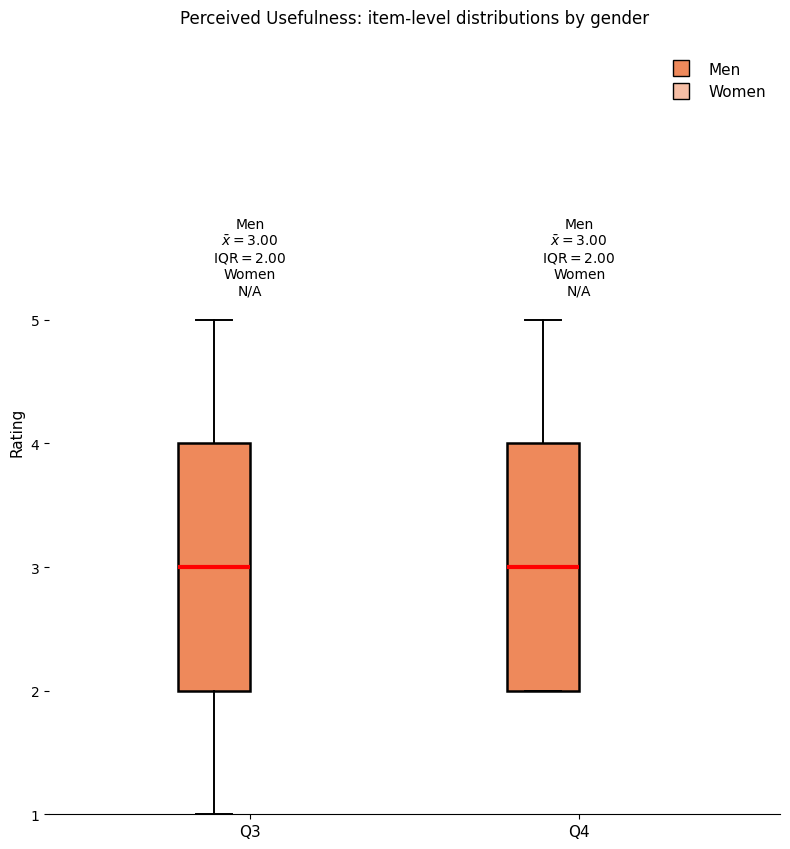

Saved: new_svg_plots/boxplot_gender_clarity.svg


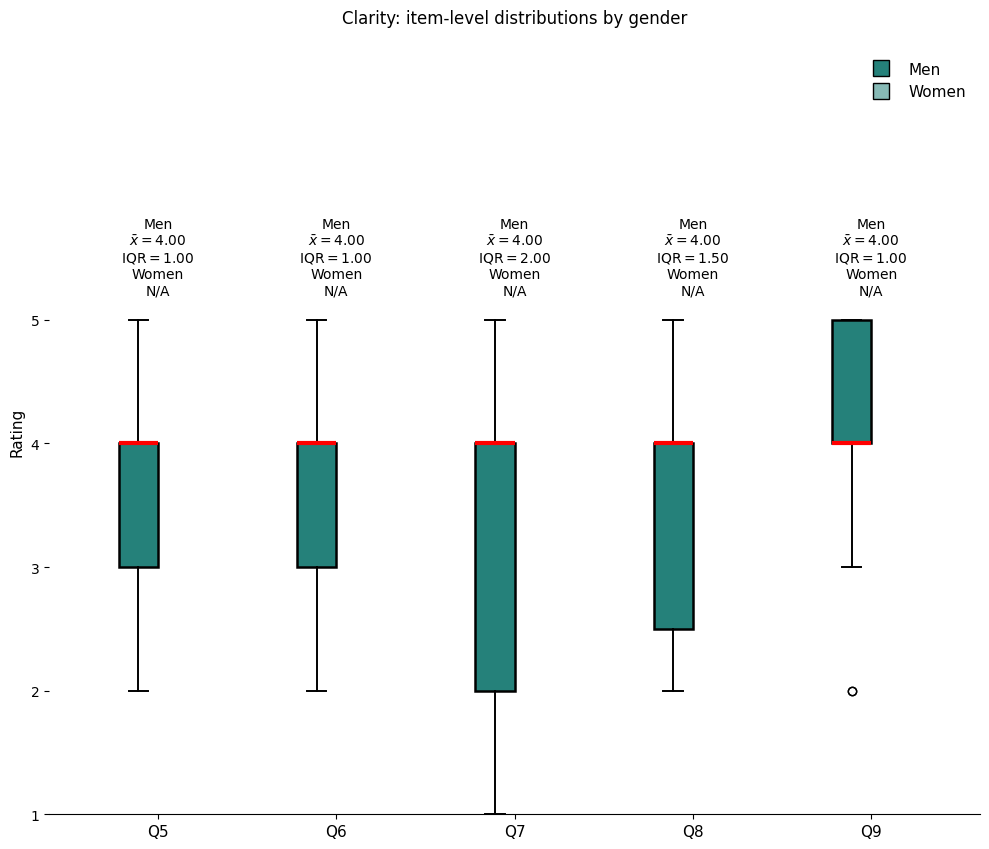

Saved: new_svg_plots/boxplot_gender_social_expressiveness__appropriateness.svg


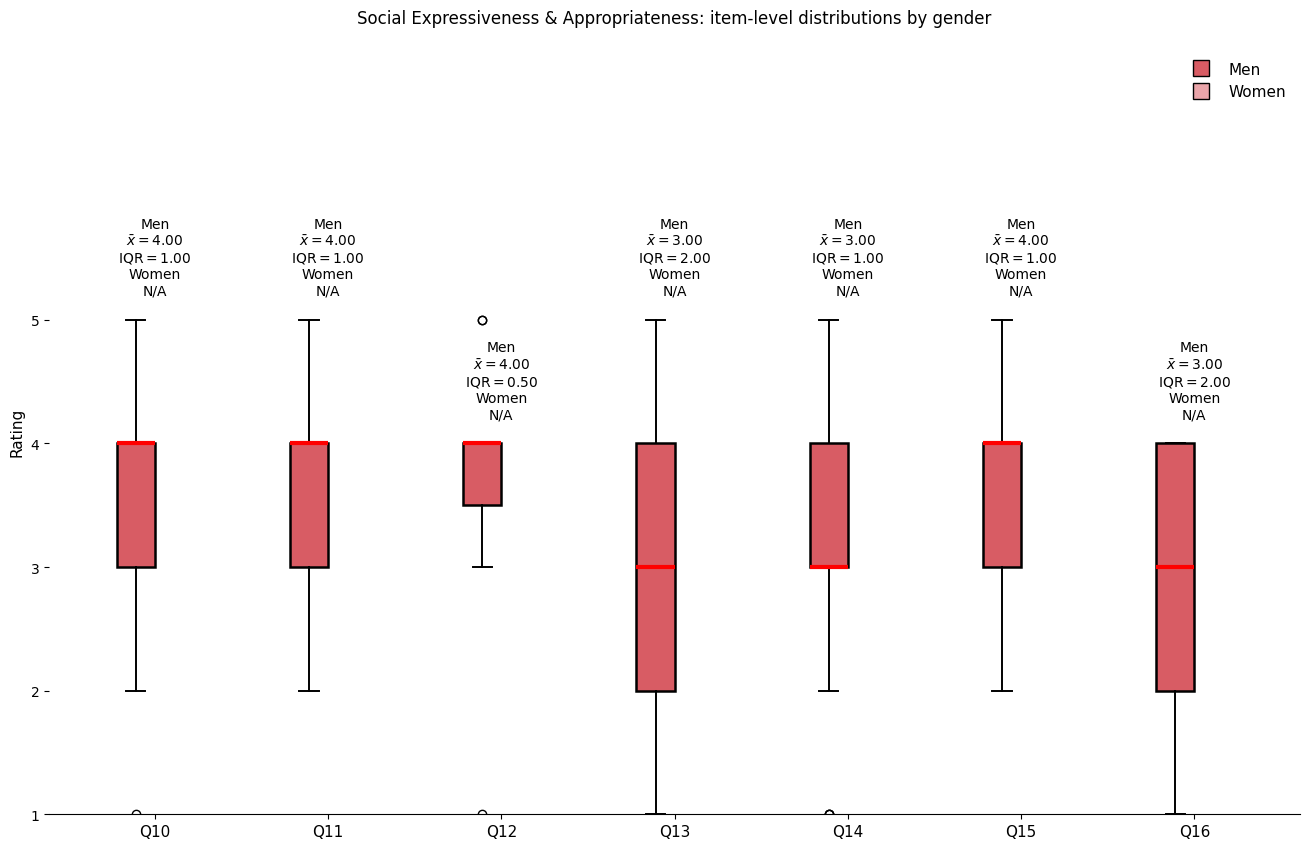

Saved: new_svg_plots/boxplot_gender_trust_safety__comfort.svg


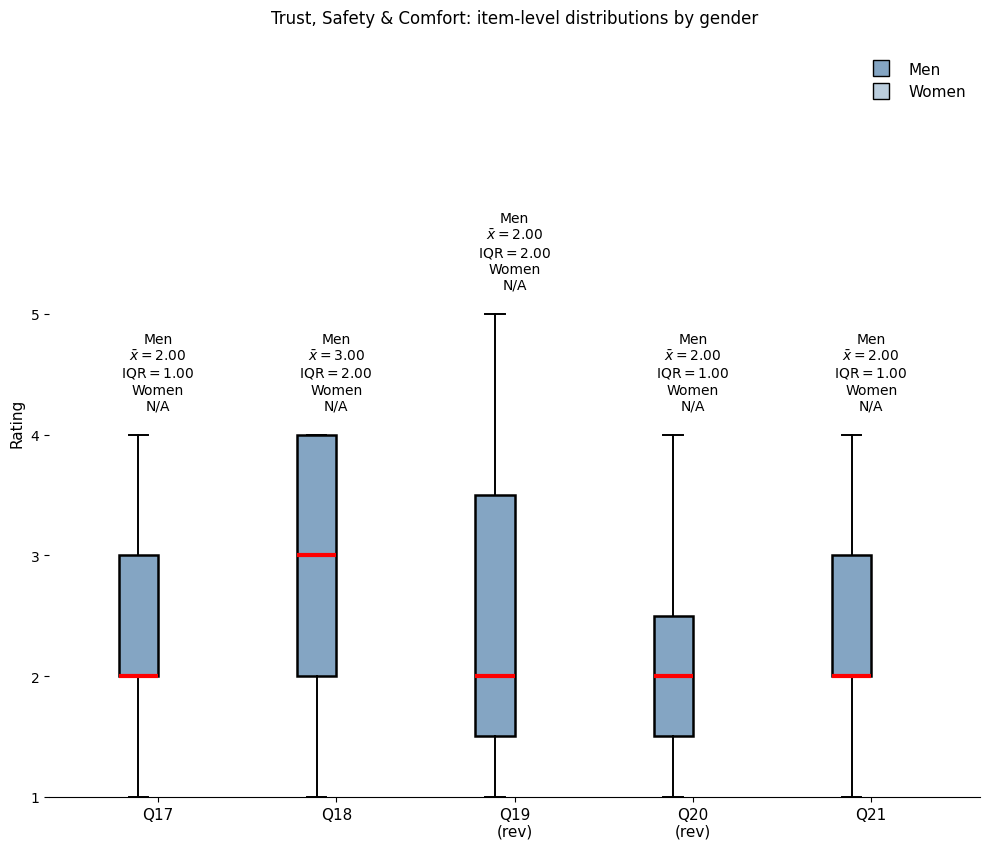

Saved: new_svg_plots/boxplot_gender_all_constructs.svg


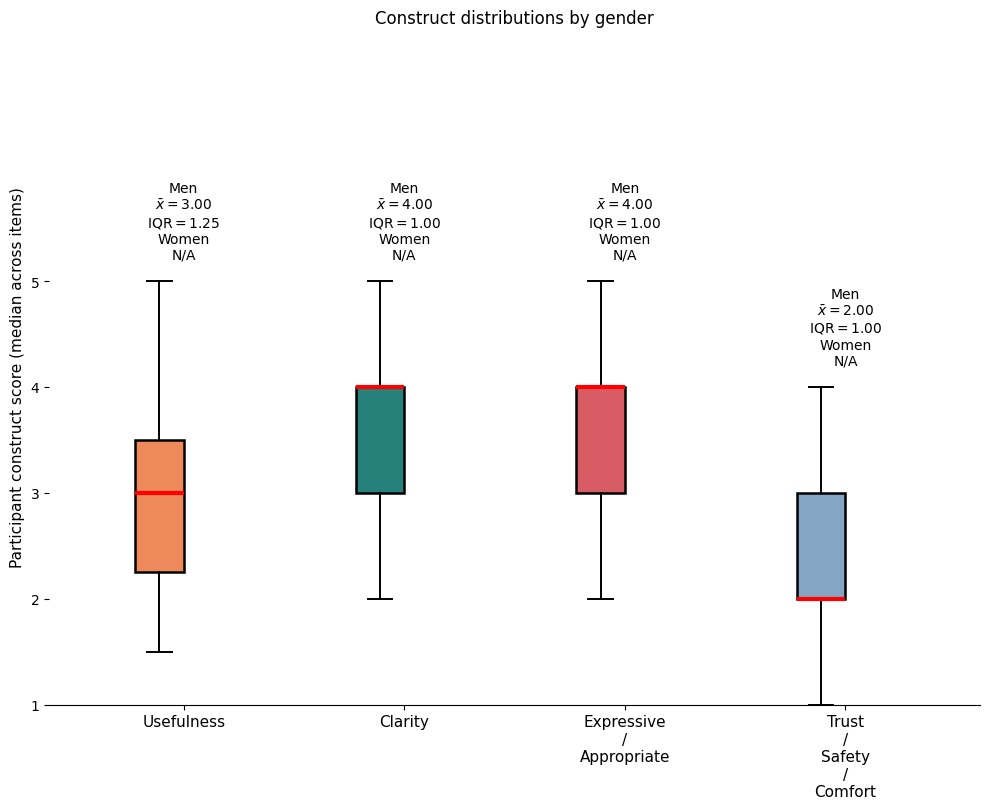

In [29]:
# Lecture-style gender comparison plots (Man vs Woman)
from matplotlib import colors as mcolors
import re

def clean_gender(x):
    """
    Collapse messy OCR gender values into:
    - Man
    - Woman
    - Other/Multiple
    - Missing
    """
    if pd.isna(x):
        return "Missing"

    s = str(x).strip().lower()

    has_woman = re.search(r"\bwoman\b", s) is not None
    has_man = re.search(r"\bman\b", s) is not None
    has_nonbinary = any(term in s for term in ["non-binary", "nonbinary", "non conforming", "non-conforming"])
    has_other = "other" in s or "prefer not" in s

    if (has_man and has_woman) or has_nonbinary or has_other:
        return "Other/Multiple"
    if has_woman:
        return "Woman"
    if has_man:
        return "Man"
    return "Other/Multiple"


GENDER_GROUPS = ["Man", "Woman"]
GENDER_GROUP_LABELS = ["Men", "Women"]
GENDER_BOX_WIDTH = 0.22
GENDER_ITEM_FIG_HEIGHT = 8.6
GENDER_ITEM_WIDTH_PER_PAIR = 1.6
GENDER_OVERALL_FIG_WIDTH = 10
GENDER_OVERALL_FIG_HEIGHT = 8.2
GENDER_YMAX = 7.2
GENDER_ANNOTATION_OFFSET = 0.18
GENDER_TITLE_PAD = 18


def lighten_color(color, amount=0.45):
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb + (1 - rgb) * amount)


def get_gender_group_colors(base_color):
    return [base_color, lighten_color(base_color)]


def add_gender_legend(ax, group_colors):
    handles = [
        plt.Line2D([0], [0], color="black", marker="s", linestyle="", markersize=12,
                   markerfacecolor=group_colors[0], label=GENDER_GROUP_LABELS[0]),
        plt.Line2D([0], [0], color="black", marker="s", linestyle="", markersize=12,
                   markerfacecolor=group_colors[1], label=GENDER_GROUP_LABELS[1]),
    ]
    ax.legend(handles=handles, frameon=False, fontsize=LABEL_FONT_SIZE)


def annotate_grouped_box(ax, left_box, right_box, xpos, left_vals, right_vals):
    left_vals = np.asarray(left_vals, dtype=float)
    right_vals = np.asarray(right_vals, dtype=float)
    left_vals = left_vals[~np.isnan(left_vals)]
    right_vals = right_vals[~np.isnan(right_vals)]

    if len(left_vals) == 0 and len(right_vals) == 0:
        return

    if len(left_vals) > 0:
        left_top = left_box["caps"][1].get_ydata()[0]
        left_annotation = (
            f"{GENDER_GROUP_LABELS[0]}\n"
            + rf"$\bar{{x}}={np.median(left_vals):.2f}$"
            + "\n"
            + rf"$\mathrm{{IQR}}={np.percentile(left_vals, 75) - np.percentile(left_vals, 25):.2f}$"
        )
    else:
        left_top = YMIN
        left_annotation = f"{GENDER_GROUP_LABELS[0]}\nN/A"

    if len(right_vals) > 0:
        right_top = right_box["caps"][1].get_ydata()[0]
        right_annotation = (
            f"{GENDER_GROUP_LABELS[1]}\n"
            + rf"$\bar{{x}}={np.median(right_vals):.2f}$"
            + "\n"
            + rf"$\mathrm{{IQR}}={np.percentile(right_vals, 75) - np.percentile(right_vals, 25):.2f}$"
        )
    else:
        right_top = YMIN
        right_annotation = f"{GENDER_GROUP_LABELS[1]}\nN/A"

    top_y = max(left_top, right_top)
    annotation = left_annotation + "\n" + right_annotation
    ax.text(xpos, top_y + GENDER_ANNOTATION_OFFSET, annotation, fontsize=ANNOTATION_FONT_SIZE, va="bottom", ha="center")


data["gender_clean"] = data["gender"].apply(clean_gender)
gender_data = data[data["gender_clean"].isin(GENDER_GROUPS)].copy()

gender_counts = gender_data["gender_clean"].value_counts().reindex(GENDER_GROUPS, fill_value=0)
display(gender_counts.rename_axis("gender").reset_index(name="n"))

for construct_name, settings in constructs_to_plot.items():
    items = settings["items"]
    labels = [pretty_item_labels.get(item, item) for item in items]
    wrapped_labels = [wrap_label(label) for label in labels]
    group_colors = get_gender_group_colors(settings["color"])

    fig_width = max(ITEM_MIN_WIDTH, len(items) * GENDER_ITEM_WIDTH_PER_PAIR + 2)
    fig, ax = plt.subplots(figsize=(fig_width, GENDER_ITEM_FIG_HEIGHT))
    positions = np.arange(len(items))

    for i, item in enumerate(items):
        men_vals = pd.to_numeric(
            gender_data.loc[gender_data["gender_clean"] == "Man", item], errors="coerce"
        ).dropna().values
        women_vals = pd.to_numeric(
            gender_data.loc[gender_data["gender_clean"] == "Woman", item], errors="coerce"
        ).dropna().values

        left_box = ax.boxplot(
            men_vals if len(men_vals) else [np.nan],
            positions=[positions[i] - GENDER_BOX_WIDTH / 2],
            widths=GENDER_BOX_WIDTH,
            patch_artist=True,
            notch=False,
            medianprops=dict(color="red", linewidth=MEDIAN_LINEWIDTH),
            whiskerprops=dict(color="black", linewidth=WHISKER_LINEWIDTH),
            capprops=dict(color="black", linewidth=CAP_LINEWIDTH),
            boxprops=dict(linewidth=BOX_LINEWIDTH),
        )
        right_box = ax.boxplot(
            women_vals if len(women_vals) else [np.nan],
            positions=[positions[i] + GENDER_BOX_WIDTH / 2],
            widths=GENDER_BOX_WIDTH,
            patch_artist=True,
            notch=False,
            medianprops=dict(color="red", linewidth=MEDIAN_LINEWIDTH),
            whiskerprops=dict(color="black", linewidth=WHISKER_LINEWIDTH),
            capprops=dict(color="black", linewidth=CAP_LINEWIDTH),
            boxprops=dict(linewidth=BOX_LINEWIDTH),
        )

        for patch in left_box["boxes"]:
            patch.set_facecolor(group_colors[0])
        for patch in right_box["boxes"]:
            patch.set_facecolor(group_colors[1])

        annotate_grouped_box(ax, left_box, right_box, positions[i], men_vals, women_vals)

    ax.set_xticks(positions)
    ax.set_xticklabels(wrapped_labels, fontsize=LABEL_FONT_SIZE, fontname=FONT_NAME)
    style_axes(ax, ylabel="Rating")
    ax.set_ylim(YMIN, GENDER_YMAX)
    add_gender_legend(ax, group_colors)
    ax.set_title(
        f"{construct_name}: item-level distributions by gender",
        fontsize=LABEL_FONT_SIZE + 1,
        fontname=FONT_NAME,
        pad=GENDER_TITLE_PAD,
    )
    fig.tight_layout()
    save_svg(fig, f"boxplot_gender_{sanitize_filename(construct_name)}.svg")

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


wrapped_labels = []
gender_construct_positions = np.arange(len(constructs_to_plot))
fig, ax = plt.subplots(figsize=(GENDER_OVERALL_FIG_WIDTH, GENDER_OVERALL_FIG_HEIGHT))

for i, (construct_name, settings) in enumerate(constructs_to_plot.items()):
    score_col = f"{construct_name}_score"
    group_colors = get_gender_group_colors(settings["color"])
    men_vals = pd.to_numeric(
        gender_data.loc[gender_data["gender_clean"] == "Man", score_col], errors="coerce"
    ).dropna().values
    women_vals = pd.to_numeric(
        gender_data.loc[gender_data["gender_clean"] == "Woman", score_col], errors="coerce"
    ).dropna().values

    left_box = ax.boxplot(
        men_vals if len(men_vals) else [np.nan],
        positions=[gender_construct_positions[i] - GENDER_BOX_WIDTH / 2],
        widths=GENDER_BOX_WIDTH,
        patch_artist=True,
        notch=False,
        medianprops=dict(color="red", linewidth=MEDIAN_LINEWIDTH),
        whiskerprops=dict(color="black", linewidth=WHISKER_LINEWIDTH),
        capprops=dict(color="black", linewidth=CAP_LINEWIDTH),
        boxprops=dict(linewidth=BOX_LINEWIDTH),
    )
    right_box = ax.boxplot(
        women_vals if len(women_vals) else [np.nan],
        positions=[gender_construct_positions[i] + GENDER_BOX_WIDTH / 2],
        widths=GENDER_BOX_WIDTH,
        patch_artist=True,
        notch=False,
        medianprops=dict(color="red", linewidth=MEDIAN_LINEWIDTH),
        whiskerprops=dict(color="black", linewidth=WHISKER_LINEWIDTH),
        capprops=dict(color="black", linewidth=CAP_LINEWIDTH),
        boxprops=dict(linewidth=BOX_LINEWIDTH),
    )

    for patch in left_box["boxes"]:
        patch.set_facecolor(group_colors[0])
    for patch in right_box["boxes"]:
        patch.set_facecolor(group_colors[1])

    annotate_grouped_box(ax, left_box, right_box, gender_construct_positions[i], men_vals, women_vals)
    wrapped_labels.append(wrap_label(settings["display"]))

ax.set_xticks(gender_construct_positions)
ax.set_xticklabels(wrapped_labels, fontsize=LABEL_FONT_SIZE, fontname=FONT_NAME)
style_axes(ax, ylabel="Participant construct score (median across items)")
ax.set_ylim(YMIN, GENDER_YMAX)
ax.set_title(
    "Construct distributions by gender",
    fontsize=LABEL_FONT_SIZE + 1,
    fontname=FONT_NAME,
    pad=GENDER_TITLE_PAD,
)
fig.tight_layout()
save_svg(fig, "boxplot_gender_all_constructs.svg")

if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)
